# GyroRun GFTM smoke test (Fusion_PhD-35kz.20)

First real exercise of YAML -> GyroRun -> notebook. 12 GFTM runs on the M1 case, built and run by GyroRun (`gyrorun_smoke` project): a 4-point ky scan and an 8-sample Latin-hypercube over ky and shat. Both leaves were saved to `pyroscan.nc` by GyroRun's chained save job, and are reopened here with pyrokinetics. The aim is to check the pipeline, not to make a physics claim.

ky is plotted as stored in the pyro object (the pyrokinetics ky coordinate). GyroRun's `units: gftm` was requested for 0.1..1.0, but the decks were written with KY = 2.25 x the request (see the README in Fusion_PhD `results/gyrorun_gftm_smoke/`), so the axis runs 0.23..2.25.

## Imports and settings

In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from pyrokinetics import PyroScan, PyroHypercube

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)

analysis_name = "gyrorun_gftm_smoke"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
code = "GFTM"
run_template = "Runs"
project = "gyrorun_smoke"
case = "M1"
scan_leaf = "ky_scan"
cube_leaf = "ky_shat_cube"
metadata_file = "pyroscan.json"
output_file = "pyroscan.nc"

## Load data

Both leaves through pyrokinetics: `PyroScan` for the scan, `PyroHypercube` for the cube.

In [2]:
scan_dir = data_root / code / run_template / project / case / scan_leaf
scan = PyroScan(pyroscan_json=scan_dir / metadata_file, load_base_pyro=True)
scan.load_gk_output(netcdf_file=scan_dir / output_file)

cube_dir = data_root / code / run_template / project / case / cube_leaf
cube = PyroHypercube(pyroscan_json=cube_dir / metadata_file, load_base_pyro=True)
cube.load_gk_output(netcdf_file=cube_dir / output_file)

## Calculate and select

Dominant mode is the mode with the largest growth rate (`max` over `mode` returns the growth rate of the `argmax` mode; no mode index is assumed). GFTM clamps stable cells to exactly 0, so zeros are counted.

In [3]:
gamma_scan = scan.gk_output.data["growth_rate"].max("mode")
gamma_cube = cube.gk_output.data["growth_rate"].max("mode")
for name, gamma in [("scan", gamma_scan), ("cube", gamma_cube)]:
    print(name, dict(gamma.sizes), "finite", int(np.isfinite(gamma.values).sum()), "/", gamma.size,
          "zero (clamped)", int((gamma.values == 0).sum()))
print("scan ky:", gamma_scan["ky"].values)
print("cube ky:", gamma_cube["ky"].values.round(3))
print("cube shat:", gamma_cube["shat"].values.round(3))

scan {'ky': 4} finite 4 / 4 zero (clamped) 0
cube {'sample': 8} finite 8 / 8 zero (clamped) 0
scan ky: [0.22524243 0.6757273  1.3514546  2.25242434]
cube ky: [2.013 0.802 1.638 1.478 1.931 0.262 1.008 0.702]
cube shat: [0.714 2.023 1.547 1.182 2.475 1.097 2.712 2.216]


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Plot

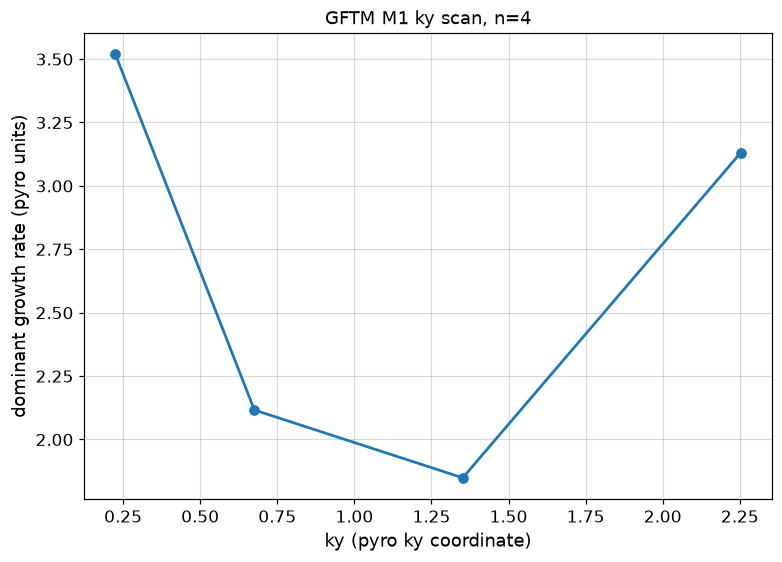

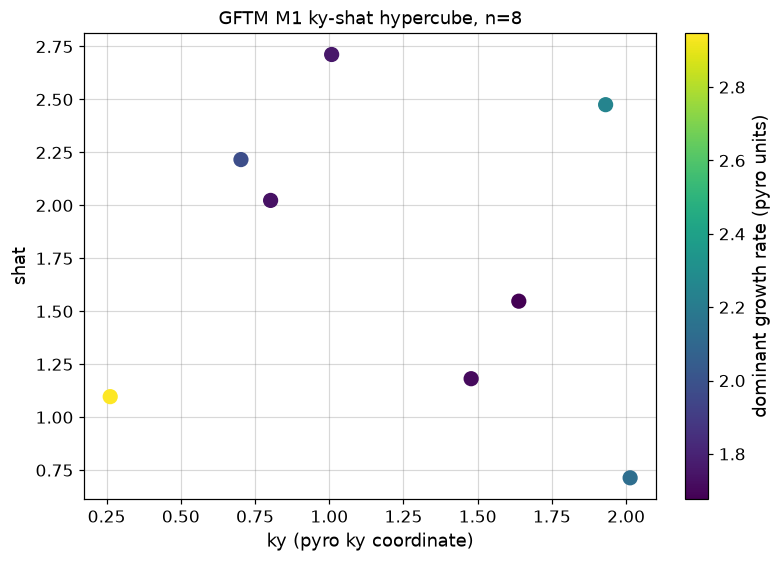

In [4]:
fig1, ax1 = plt.subplots()
ax1.plot(gamma_scan["ky"].values, gamma_scan.values)
ax1.set(xlabel="ky (pyro ky coordinate)", ylabel="dominant growth rate (pyro units)",
        title=f"GFTM M1 ky scan, n={gamma_scan.size}")

fig2, ax2 = plt.subplots()
sc = ax2.scatter(gamma_cube["ky"].values, gamma_cube["shat"].values, c=gamma_cube.values, s=80, marker="o")
fig2.colorbar(sc, ax=ax2, label="dominant growth rate (pyro units)")
ax2.set(xlabel="ky (pyro ky coordinate)", ylabel="shat",
        title=f"GFTM M1 ky-shat hypercube, n={gamma_cube.size}")
plt.show()

## Save

In [5]:
output_dir = ROOT / "Plots" / analysis_name
output_dir.mkdir(parents=True, exist_ok=True)
fig1.savefig(output_dir / "growth_rate_vs_ky.png")
fig2.savefig(output_dir / "cube_ky_shat_growth_rate.png")

## Interpretation

Pipeline check only: both `pyroscan.nc` files reopen through pyrokinetics with finite growth rates for every run. With n = 12 and an unvalidated ky normalisation (see above) no physical conclusion is drawn.